# Sistema Experto - Control Climatico de Edificios
**UT3T1 - Diseño e implementacion de un sistema experto con Experta**

He elegido hacer un sistema que controle la climatizacion de un edificio. La idea es que reciba
datos de sensores (temperatura, humedad, CO2 y ocupacion) y decida que hacer: encender calefaccion,
refrigeracion, ventilar, etc. Tambien he añadido un modelo de series temporales que predice la
temperatura para que el sistema pueda actuar antes de que haga falta.

## Imports

In [1]:
# Si no tienes las librerias instaladas, descomenta la linea de abajo y ejecuta
# !pip install experta scikit-learn matplotlib pandas numpy

# --- Parche para que experta funcione en Python 3.10+ ---
# En Python 3.10 quitaron collections.Mapping y lo movieron a collections.abc.Mapping
# pero experta sigue usando el viejo, asi que peta con AttributeError
# Lo encontre en los issues de GitHub de experta:
# https://github.com/nilp0inter/experta/issues/55
import collections
if not hasattr(collections, 'Mapping'):
    import collections.abc
    collections.Mapping = collections.abc.Mapping

# Importamos todo de experta (Rule, Fact, Field, KnowledgeEngine, etc.)
from experta import *

# Librerias de datos y graficos
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Para el modelo de series temporales
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Para las fechas de los datos sinteticos
from datetime import datetime, timedelta

# Para que no salgan warnings de sklearn que no nos interesan
import warnings
warnings.filterwarnings('ignore')

print("Imports OK")

Imports OK


## Hechos
Defino los hechos con Field igual que en el ejemplo de la sesion 1bis.
Hay 4 tipos de sensores como entrada y luego hechos que se van creando por las reglas.

In [2]:
# =============================================
# HECHOS DEL SISTEMA
# =============================================
# Los hechos son como las "variables" del sistema experto.
# Cada clase es un tipo de hecho con sus campos (Field).
# mandatory=True significa que ese campo es obligatorio.
# Es igual que en la sesion 1bis cuando definiamos Persona con nombre, edad, etc.

# --- Sensores (datos de entrada) ---
# Estos son los datos que "leen" los sensores del edificio

class SensorTemperatura(Fact):
    """Lectura del sensor de temperatura de una zona"""
    zona = Field(str, mandatory=True)        # en que zona del edificio esta
    valor = Field(float, mandatory=True)     # temperatura en grados celsius
    timestamp = Field(str, default="2026-03-14T12:00:00")  # cuando se leyo

class SensorHumedad(Fact):
    """Lectura del sensor de humedad"""
    zona = Field(str, mandatory=True)
    valor = Field(float, mandatory=True)     # porcentaje de humedad (0-100%)

class SensorOcupacion(Fact):
    """Cuanta gente hay en la zona"""
    zona = Field(str, mandatory=True)
    personas = Field(int, mandatory=True)    # numero de personas

class SensorCO2(Fact):
    """Nivel de CO2 en el aire"""
    zona = Field(str, mandatory=True)
    ppm = Field(float, mandatory=True)       # partes por millon (ppm)

# Este hecho viene del modelo de series temporales (lo definimos mas abajo)
class PrediccionTemperatura(Fact):
    """Prediccion de temperatura futura que genera el modelo"""
    zona = Field(str, mandatory=True)
    valor_futuro = Field(float, mandatory=True)  # temperatura que se predice
    horizonte_min = Field(int, default=30)        # dentro de cuantos minutos

# --- Hechos derivados ---
# Estos NO los metemos nosotros, los crean las reglas automaticamente.
# Es la "inferencia multinivel": los sensores generan estos hechos,
# y estos hechos a su vez disparan otras reglas.

class NivelConfort(Fact):
    """Clasificacion del confort termico (lo crea una regla, no el usuario)"""
    zona = Field(str, mandatory=True)
    nivel = Field(str, mandatory=True)       # puede ser: frio, optimo, caluroso

class NivelCalidadAire(Fact):
    """Clasificacion de la calidad del aire (lo crea una regla)"""
    zona = Field(str, mandatory=True)
    nivel = Field(str, mandatory=True)       # puede ser: bueno, regular, malo

class RiesgoEnergetico(Fact):
    """Si hay riesgo de gastar demasiada energia (lo crea una regla)"""
    zona = Field(str, mandatory=True)
    nivel = Field(str, mandatory=True)       # alto, medio, bajo

# --- Hechos de salida ---
# Las decisiones finales del sistema

class AccionControl(Fact):
    """Accion que hay que ejecutar (encender calefaccion, ventilar, etc.)"""
    zona = Field(str, mandatory=True)
    sistema = Field(str, mandatory=True)     # hvac, ventilacion, deshumidificador
    accion = Field(str, mandatory=True)      # que hacer (calefaccion, refrigeracion...)
    intensidad = Field(str, default="media") # alta, media, baja, moderada

class Alerta(Fact):
    """Alerta para el operador del edificio"""
    zona = Field(str, mandatory=True)
    tipo = Field(str, mandatory=True)        # evacuacion, aviso, etc.
    mensaje = Field(str, default="")
    prioridad = Field(str, default="media")  # critica, alta, media, baja

class EstadoSistema(Fact):
    """Estado general del sistema (normal, ahorro, emergencia)"""
    modo = Field(str, default="normal")

print("Hechos definidos: 11 tipos en total")

Hechos definidos: 11 tipos en total


## Motor de inferencia

Las reglas las he organizado con salience en 4 niveles, como vi en la guia tecnica que
el motor ejecuta primero las de mayor salience:
- salience 100: emergencias (lo primero es comprobar si hay peligro)
- salience 50: clasificar los datos de los sensores
- salience 20: decidir acciones de control
- salience 10: ajustes y optimizacion

En total son 17 reglas.

In [3]:
# =============================================
# MOTOR DE INFERENCIA (las reglas)
# =============================================
# KnowledgeEngine es el motor que ejecuta las reglas.
# Cada metodo con @Rule es una regla que se dispara cuando se cumplen las condiciones.
#
# He organizado las reglas con salience (prioridad):
#   - salience=100: emergencias (lo mas urgente, se ejecuta primero)
#   - salience=50:  clasificar datos de sensores en categorias
#   - salience=20:  decidir acciones de control (calefaccion, ventilacion, etc.)
#   - salience=10:  optimizacion y ajustes finales
#
# Esto es importante porque si no usas salience, las reglas se ejecutan en cualquier
# orden y puede pasar que una regla de control busque NivelConfort pero todavia no
# se ha creado porque la regla de clasificacion no se ha ejecutado aun.

class ControlClimatico(KnowledgeEngine):

    # DefFacts se ejecuta automaticamente cuando haces reset().
    # Es como poner los hechos iniciales del sistema.
    @DefFacts()
    def hechos_iniciales(self):
        """Hecho inicial: el sistema arranca en modo normal"""
        yield EstadoSistema(modo="normal")

    # =========================================
    # EMERGENCIAS (salience=100)
    # =========================================
    # Lo primero siempre es comprobar si hay peligro.
    # Estas reglas van primero porque tienen el salience mas alto.

    @Rule(
        # P() es un predicado: comprueba una condicion con lambda
        # MATCH.zona captura el valor de zona para usarlo despues
        SensorTemperatura(zona=MATCH.zona, valor=P(lambda t: t > 45 or t < 0)),
        salience=100
    )
    def emergencia_temp(self, zona):
        """Si la temperatura es extrema (>45 o <0), hay que evacuar"""
        print(f"  EMERGENCIA: Zona '{zona}' - temperatura extrema")
        # Declaramos una alerta critica
        self.declare(Alerta(
            zona=zona, tipo="evacuacion",
            mensaje=f"Temperatura extrema en {zona}, evacuar",
            prioridad="critica"
        ))
        # Y una accion de parada de emergencia
        self.declare(AccionControl(
            zona=zona, sistema="hvac", accion="parada_emergencia", intensidad="maxima"
        ))

    @Rule(
        SensorCO2(zona=MATCH.zona, ppm=P(lambda c: c > 5000)),
        salience=100
    )
    def emergencia_co2(self, zona):
        """CO2 por encima de 5000 ppm es toxico, hay que evacuar y ventilar"""
        print(f"  EMERGENCIA: Zona '{zona}' - CO2 toxico (>5000 ppm)")
        self.declare(Alerta(
            zona=zona, tipo="evacuacion",
            mensaje=f"CO2 toxico en {zona}, evacuar y ventilar",
            prioridad="critica"
        ))
        self.declare(AccionControl(
            zona=zona, sistema="ventilacion", accion="ventilacion_emergencia", intensidad="maxima"
        ))

    # =========================================
    # CLASIFICACION (salience=50)
    # =========================================
    # Aqui transformamos los datos brutos de los sensores en categorias.
    # Por ejemplo: 15 grados -> "frio", 22 grados -> "optimo"
    # Esto es la inferencia multinivel: estos hechos nuevos disparan las reglas de control.
    #
    # Importante: uso NOT(Alerta(prioridad="critica")) para que no clasifique
    # durante una emergencia. Si no, podria intentar poner calefaccion en una
    # zona que hay que evacuar, lo cual no tiene sentido.

    @Rule(
        SensorTemperatura(zona=MATCH.zona, valor=P(lambda t: t < 19)),
        # L() compara con un valor literal exacto
        NOT(Alerta(zona=MATCH.zona, prioridad=L("critica"))),
        salience=50
    )
    def clasificar_frio(self, zona):
        """Menos de 19 grados = frio"""
        print(f"  Clasificacion: Zona '{zona}' -> FRIO")
        # Este hecho nuevo (NivelConfort) disparara la regla de calefaccion
        self.declare(NivelConfort(zona=zona, nivel="frio"))

    @Rule(
        SensorTemperatura(zona=MATCH.zona, valor=P(lambda t: t > 26)),
        NOT(Alerta(zona=MATCH.zona, prioridad=L("critica"))),
        salience=50
    )
    def clasificar_calor(self, zona):
        """Mas de 26 grados = caluroso"""
        print(f"  Clasificacion: Zona '{zona}' -> CALUROSO")
        self.declare(NivelConfort(zona=zona, nivel="caluroso"))

    @Rule(
        # 19 <= t <= 26 es el rango optimo
        SensorTemperatura(zona=MATCH.zona, valor=P(lambda t: 19 <= t <= 26)),
        NOT(Alerta(zona=MATCH.zona, prioridad=L("critica"))),
        salience=50
    )
    def clasificar_optimo(self, zona):
        """Entre 19 y 26 grados = temperatura optima"""
        print(f"  Clasificacion: Zona '{zona}' -> OPTIMO")
        self.declare(NivelConfort(zona=zona, nivel="optimo"))

    @Rule(
        # CO2 entre 1000 y 5000 ppm es malo pero no emergencia
        SensorCO2(zona=MATCH.zona, ppm=P(lambda c: c > 1000 and c <= 5000)),
        salience=50
    )
    def clasificar_aire_malo(self, zona):
        """CO2 alto (1001-5000 ppm) = aire malo, hay que ventilar"""
        print(f"  Clasificacion: Zona '{zona}' -> aire MALO")
        self.declare(NivelCalidadAire(zona=zona, nivel="malo"))

    @Rule(
        SensorCO2(zona=MATCH.zona, ppm=P(lambda c: 400 < c <= 1000)),
        salience=50
    )
    def clasificar_aire_regular(self, zona):
        """CO2 medio (401-1000 ppm) = aire regular, no es urgente"""
        print(f"  Clasificacion: Zona '{zona}' -> aire REGULAR")
        self.declare(NivelCalidadAire(zona=zona, nivel="regular"))

    @Rule(
        SensorCO2(zona=MATCH.zona, ppm=P(lambda c: c <= 400)),
        salience=50
    )
    def clasificar_aire_bueno(self, zona):
        """CO2 bajo (<=400 ppm) = aire bueno"""
        print(f"  Clasificacion: Zona '{zona}' -> aire BUENO")
        self.declare(NivelCalidadAire(zona=zona, nivel="bueno"))

    @Rule(
        # Mas de 30 personas en la zona
        SensorOcupacion(zona=MATCH.zona, personas=P(lambda p: p > 30)),
        # OR() comprueba que se cumpla al menos una de las dos condiciones
        # es decir: que haga frio O que haga calor (no optimo)
        OR(NivelConfort(zona=MATCH.zona, nivel=L("frio")),
           NivelConfort(zona=MATCH.zona, nivel=L("caluroso"))),
        salience=50
    )
    def riesgo_energetico(self, zona):
        """Mucha gente + temp no optima = va a gastar mucha energia"""
        print(f"  Clasificacion: Zona '{zona}' -> riesgo energetico ALTO")
        self.declare(RiesgoEnergetico(zona=zona, nivel="alto"))

    # =========================================
    # CONTROL (salience=20)
    # =========================================
    # Aqui es donde se toman las decisiones: encender calefaccion, ventilar, etc.
    # Estas reglas necesitan que ya existan los hechos de clasificacion (NivelConfort),
    # por eso tienen salience mas bajo que las de clasificacion.
    #
    # Uso NOT(AccionControl(...)) en todas para evitar duplicar acciones.
    # Sin esto, el motor declaraba la misma accion varias veces.

    @Rule(
        NivelConfort(zona=MATCH.zona, nivel=L("frio")),
        # Solo si hay gente, si no no tiene sentido calentar
        SensorOcupacion(zona=MATCH.zona, personas=P(lambda p: p > 0)),
        # Comprobar que no se haya puesto ya calefaccion
        NOT(AccionControl(zona=MATCH.zona, accion=L("calefaccion"))),
        # Y que no haya emergencia
        NOT(Alerta(zona=MATCH.zona, prioridad=L("critica"))),
        salience=20
    )
    def activar_calefaccion(self, zona):
        """Hace frio y hay gente -> encender calefaccion"""
        print(f"  Control: Zona '{zona}' -> activar CALEFACCION")
        self.declare(AccionControl(
            zona=zona, sistema="hvac", accion="calefaccion", intensidad="alta"
        ))

    @Rule(
        NivelConfort(zona=MATCH.zona, nivel=L("caluroso")),
        SensorOcupacion(zona=MATCH.zona, personas=P(lambda p: p > 0)),
        NOT(AccionControl(zona=MATCH.zona, accion=L("refrigeracion"))),
        NOT(Alerta(zona=MATCH.zona, prioridad=L("critica"))),
        salience=20
    )
    def activar_refrigeracion(self, zona):
        """Hace calor y hay gente -> encender aire acondicionado"""
        print(f"  Control: Zona '{zona}' -> activar REFRIGERACION")
        self.declare(AccionControl(
            zona=zona, sistema="hvac", accion="refrigeracion", intensidad="alta"
        ))

    @Rule(
        NivelCalidadAire(zona=MATCH.zona, nivel=L("malo")),
        NOT(AccionControl(zona=MATCH.zona, accion=L("ventilacion"))),
        NOT(AccionControl(zona=MATCH.zona, accion=L("ventilacion_emergencia"))),
        salience=20
    )
    def ventilacion_forzada(self, zona):
        """Aire malo -> ventilar a tope"""
        print(f"  Control: Zona '{zona}' -> VENTILACION forzada")
        self.declare(AccionControl(
            zona=zona, sistema="ventilacion", accion="ventilacion", intensidad="alta"
        ))

    @Rule(
        NivelConfort(zona=MATCH.zona, nivel=L("optimo")),
        # L(0) compara con el valor exacto 0 (cero personas)
        SensorOcupacion(zona=MATCH.zona, personas=L(0)),
        NOT(AccionControl(zona=MATCH.zona)),
        salience=20
    )
    def modo_ahorro(self, zona):
        """No hay nadie y la temp esta bien -> modo ahorro para gastar menos"""
        print(f"  Control: Zona '{zona}' -> MODO AHORRO (vacia)")
        self.declare(AccionControl(
            zona=zona, sistema="hvac", accion="modo_ahorro", intensidad="baja"
        ))

    @Rule(
        # Esta regla usa la prediccion del modelo de series temporales
        # Si se predice que va a superar 28 grados en 30 minutos...
        PrediccionTemperatura(zona=MATCH.zona, valor_futuro=P(lambda t: t > 28)),
        # ...pero ahora la temp esta bien...
        NivelConfort(zona=MATCH.zona, nivel=L("optimo")),
        # ...y hay gente en la zona...
        SensorOcupacion(zona=MATCH.zona, personas=P(lambda p: p > 0)),
        NOT(AccionControl(zona=MATCH.zona, accion=L("pre_enfriamiento"))),
        salience=20
    )
    def control_predictivo(self, zona):
        """La prediccion dice que va a subir -> pre-enfriar antes de que pase"""
        print(f"  Control predictivo: Zona '{zona}' -> PRE-ENFRIAMIENTO")
        self.declare(AccionControl(
            zona=zona, sistema="hvac", accion="pre_enfriamiento", intensidad="media"
        ))

    # =========================================
    # OPTIMIZACION (salience=10)
    # =========================================
    # Ajustes finales para resolver conflictos entre reglas.
    # Por ejemplo: hace calor y hay que refrigerar, pero hay tanta gente
    # que gastar a tope seria demasiado -> se baja la intensidad.

    @Rule(
        # AS.accion << ... captura el hecho en la variable 'accion'
        # para poder modificarlo despues con self.modify()
        # Es igual que AS.cs << Fact(credito=...) del ejemplo de prestamos
        AS.accion << AccionControl(zona=MATCH.zona, accion=L("refrigeracion"), intensidad=L("alta")),
        RiesgoEnergetico(zona=MATCH.zona, nivel=L("alto")),
        salience=10
    )
    def conflicto_confort_energia(self, accion, zona):
        """Hay que enfriar pero gastaria demasiado -> bajar intensidad a moderada"""
        print(f"  Optimizacion: Zona '{zona}' -> bajar refrigeracion a MODERADA")
        # modify() cambia un campo del hecho sin borrarlo y volver a crearlo
        self.modify(accion, intensidad="moderada")

    @Rule(
        # Humedad alta (>70%) + calor = sensacion termica peor
        SensorHumedad(zona=MATCH.zona, valor=P(lambda h: h > 70)),
        NivelConfort(zona=MATCH.zona, nivel=L("caluroso")),
        NOT(AccionControl(zona=MATCH.zona, sistema=L("deshumidificador"))),
        salience=10
    )
    def ajuste_humedad(self, zona):
        """Calor + humedad alta = muy incomodo, activar deshumidificador"""
        print(f"  Optimizacion: Zona '{zona}' -> activar DESHUMIDIFICADOR")
        self.declare(AccionControl(
            zona=zona, sistema="deshumidificador", accion="deshumidificar", intensidad="alta"
        ))

    @Rule(
        # Aire regular (no malo, pero tampoco bueno) + bastante gente
        NivelCalidadAire(zona=MATCH.zona, nivel=L("regular")),
        SensorOcupacion(zona=MATCH.zona, personas=P(lambda p: p > 15)),
        NOT(AccionControl(zona=MATCH.zona, accion=L("ventilacion"))),
        NOT(AccionControl(zona=MATCH.zona, accion=L("ventilacion_emergencia"))),
        salience=10
    )
    def ventilacion_preventiva(self, zona):
        """Aire regular + mucha gente -> ventilar un poco por prevencion"""
        print(f"  Optimizacion: Zona '{zona}' -> ventilacion preventiva")
        self.declare(AccionControl(
            zona=zona, sistema="ventilacion", accion="ventilacion", intensidad="baja"
        ))

print("Motor definido con 17 reglas")

Motor definido con 17 reglas


## Series temporales
Genero datos de temperatura de 7 dias (una lectura por hora) y entreno un modelo
para predecir la temperatura futura. Asi el sistema puede pre-enfriar antes de que suba.

In [4]:
# =============================================
# GENERAR DATOS SINTETICOS DE TEMPERATURA
# =============================================
# Como no tenemos sensores reales, generamos datos falsos pero realistas.
# Simulamos 7 dias (168 horas) con:
#   - Ciclo dia/noche: sube por el dia, baja por la noche (con seno)
#   - Efecto fin de semana: 2 grados menos (menos actividad en el edificio)
#   - Tendencia: sube un poco cada dia (como si se acercase el verano)
#   - Ruido: variacion aleatoria para que no sea perfecto

def generar_datos_temp(dias=7, seed=42):
    np.random.seed(seed)  # semilla fija para que siempre salga igual
    fechas = []
    temps = []
    inicio = datetime(2026, 3, 7, 0, 0)  # empezamos un sabado

    for d in range(dias):
        for h in range(24):
            fecha = inicio + timedelta(days=d, hours=h)

            # Cada componente aporta algo a la temperatura final
            base = 22.0                                          # temperatura base del edificio
            ciclo = 4.0 * np.sin(2 * np.pi * (h - 8) / 24)     # sube de dia, baja de noche
            finde = -2.0 if fecha.weekday() >= 5 else 0.0       # fines de semana mas frio
            tendencia = 0.3 * d                                  # sube un poco cada dia
            ruido = np.random.normal(0, 1.5)                     # variacion aleatoria

            temps.append(round(base + ciclo + finde + tendencia + ruido, 1))
            fechas.append(fecha)

    # Metemos todo en un DataFrame de pandas para manejarlo mejor
    df = pd.DataFrame({
        'fecha': fechas,
        'hora': [f.hour for f in fechas],
        'dia_semana': [f.weekday() for f in fechas],
        'temperatura': temps,
        'zona': 'oficina_norte'
    })
    return df

# Generamos los datos y vemos un resumen
df_temperatura = generar_datos_temp()

print(f"Datos generados: {len(df_temperatura)} registros")
print(f"Rango: {df_temperatura['fecha'].min()} a {df_temperatura['fecha'].max()}")
print(f"Temp media: {df_temperatura['temperatura'].mean():.1f}C")
print(f"Temp min: {df_temperatura['temperatura'].min():.1f}C, max: {df_temperatura['temperatura'].max():.1f}C")
print()
df_temperatura.head(10)

Datos generados: 168 registros
Rango: 2026-03-07 00:00:00 a 2026-03-13 23:00:00
Temp media: 22.3C
Temp min: 14.6C, max: 30.1C



,fecha,hora,dia_semana,temperatura,zona
0,2026-03-07 00:00:00,0,5,17.3,oficina_norte
1,2026-03-07 01:00:00,1,5,15.9,oficina_norte
2,2026-03-07 02:00:00,2,5,17.0,oficina_norte
3,2026-03-07 03:00:00,3,5,18.4,oficina_norte
4,2026-03-07 04:00:00,4,5,16.2,oficina_norte
5,2026-03-07 05:00:00,5,5,16.8,oficina_norte
6,2026-03-07 06:00:00,6,5,20.4,oficina_norte
7,2026-03-07 07:00:00,7,5,20.1,oficina_norte
8,2026-03-07 08:00:00,8,5,19.3,oficina_norte
9,2026-03-07 09:00:00,9,5,21.8,oficina_norte


### Entrenar el modelo
Uso regresion polinomial de grado 3. Para la hora uso codificacion ciclica (seno y coseno)
porque si no el modelo no entiende que las 23h estan cerca de las 0h.

In [5]:
# =============================================
# ENTRENAR MODELO DE PREDICCION
# =============================================
# Usamos regresion polinomial (grado 3) para predecir la temperatura
# a partir de la hora y el dia de la semana.
#
# Truco importante: la hora se codifica con seno y coseno (codificacion ciclica)
# porque si pones la hora directamente (0, 1, 2, ..., 23), el modelo pensaria
# que las 23h y las 0h estan muy lejos, cuando en realidad estan al lado.
# Con seno y coseno se resuelve esto.

def entrenar_modelo(df):
    df_feat = df.copy()

    # Codificacion ciclica de la hora (el truco del seno/coseno)
    df_feat['hora_sin'] = np.sin(2 * np.pi * df_feat['hora'] / 24)
    df_feat['hora_cos'] = np.cos(2 * np.pi * df_feat['hora'] / 24)

    # Si es fin de semana o no (1 = finde, 0 = entre semana)
    df_feat['es_finde'] = (df_feat['dia_semana'] >= 5).astype(int)

    # X = las variables de entrada, y = lo que queremos predecir (temperatura)
    X = df_feat[['hora_sin', 'hora_cos', 'dia_semana', 'es_finde']].values
    y = df_feat['temperatura'].values

    # make_pipeline encadena los pasos: primero genera las features polinomiales
    # y luego aplica la regresion lineal sobre esas features
    modelo = make_pipeline(
        PolynomialFeatures(degree=3, include_bias=False),  # genera combinaciones de grado 3
        LinearRegression()                                  # regresion lineal
    )
    modelo.fit(X, y)  # entrenar el modelo

    # Evaluamos como de bien predice
    y_pred = modelo.predict(X)
    rmse = np.sqrt(np.mean((y - y_pred) ** 2))  # error medio (cuanto se equivoca)
    r2 = modelo.score(X, y)                       # R2: 1.0 = perfecto, 0.0 = malo
    print(f"Modelo entrenado - RMSE: {rmse:.2f}C, R2: {r2:.4f}")

    return modelo

def predecir_temp(modelo, hora, dia_semana):
    """Predice la temperatura para una hora y dia concretos"""
    # Convertimos la hora a seno/coseno (igual que al entrenar)
    hora_sin = np.sin(2 * np.pi * hora / 24)
    hora_cos = np.cos(2 * np.pi * hora / 24)
    es_finde = 1 if dia_semana >= 5 else 0

    # Creamos el array con las features y predecimos
    X = np.array([[hora_sin, hora_cos, dia_semana, es_finde]])
    return round(float(modelo.predict(X)[0]), 1)

# Entrenamos el modelo con los datos que generamos antes
modelo_temp = entrenar_modelo(df_temperatura)

# Probamos unas cuantas predicciones para ver si tiene sentido
print("\nPredicciones de ejemplo (lunes, dia_semana=0):")
for h in [8, 12, 14, 18, 22]:
    pred = predecir_temp(modelo_temp, h, 0)
    print(f"  {h:02d}:00 -> {pred}C")

Modelo entrenado - RMSE: 1.33C, R2: 0.8523



Predicciones de ejemplo (lunes, dia_semana=0):
  08:00 -> 23.1C
  12:00 -> 25.7C
  14:00 -> 26.3C
  18:00 -> 25.3C
  22:00 -> 20.7C


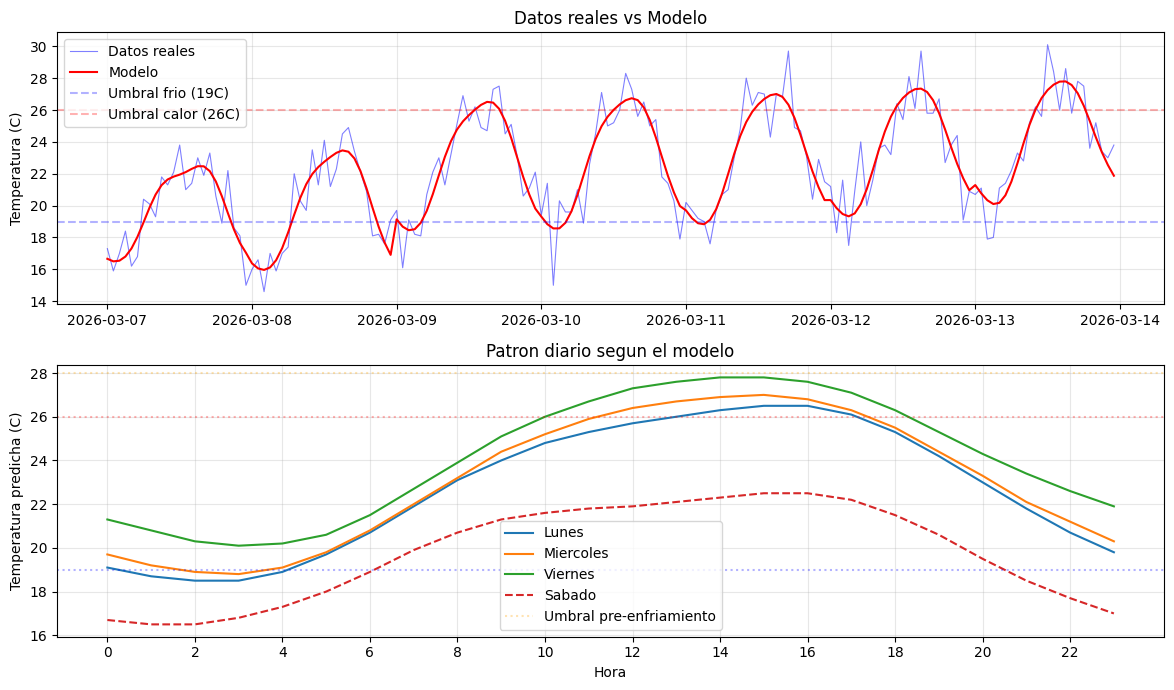

In [6]:
# =============================================
# GRAFICO: datos reales vs prediccion del modelo
# =============================================
# Arriba: la linea azul son los datos reales y la roja lo que predice el modelo.
# Abajo: como varia la prediccion segun el dia de la semana.

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7))

# --- Grafico 1: datos reales vs modelo ---
ax1.plot(df_temperatura['fecha'], df_temperatura['temperatura'],
         'b-', alpha=0.5, linewidth=0.8, label='Datos reales')

# Preparamos las features para predecir sobre todos los datos
df_pred = df_temperatura.copy()
df_pred['hora_sin'] = np.sin(2 * np.pi * df_pred['hora'] / 24)
df_pred['hora_cos'] = np.cos(2 * np.pi * df_pred['hora'] / 24)
df_pred['es_finde'] = (df_pred['dia_semana'] >= 5).astype(int)
X_all = df_pred[['hora_sin', 'hora_cos', 'dia_semana', 'es_finde']].values
y_modelo = modelo_temp.predict(X_all)

ax1.plot(df_temperatura['fecha'], y_modelo, 'r-', linewidth=1.5, label='Modelo')
# Lineas de los umbrales del sistema experto
ax1.axhline(y=19, color='blue', linestyle='--', alpha=0.3, label='Umbral frio (19C)')
ax1.axhline(y=26, color='red', linestyle='--', alpha=0.3, label='Umbral calor (26C)')
ax1.set_ylabel('Temperatura (C)')
ax1.set_title('Datos reales vs Modelo')
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- Grafico 2: patron por dia de la semana ---
# Se ve como el sabado baja porque hay menos actividad
for nombre, dia in [('Lunes', 0), ('Miercoles', 2), ('Viernes', 4), ('Sabado', 5)]:
    preds = [predecir_temp(modelo_temp, h, dia) for h in range(24)]
    estilo = '--' if dia >= 5 else '-'  # linea discontinua para finde
    ax2.plot(range(24), preds, estilo, linewidth=1.5, label=nombre)

ax2.axhline(y=19, color='blue', linestyle=':', alpha=0.3)
ax2.axhline(y=26, color='red', linestyle=':', alpha=0.3)
ax2.axhline(y=28, color='orange', linestyle=':', alpha=0.3, label='Umbral pre-enfriamiento')
ax2.set_xlabel('Hora')
ax2.set_ylabel('Temperatura predicha (C)')
ax2.set_title('Patron diario segun el modelo')
ax2.set_xticks(range(0, 24, 2))
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Ejecucion de escenarios
Funcion auxiliar para no repetir codigo cada vez que pruebo un escenario.

In [7]:
# =============================================
# FUNCION AUXILIAR PARA EJECUTAR ESCENARIOS
# =============================================
# Para no repetir el mismo codigo cada vez que quiero probar un caso,
# esta funcion crea el motor, mete los hechos, ejecuta las reglas
# y muestra los resultados.

def ejecutar_escenario(nombre, hechos):
    """Ejecuta un escenario con los hechos dados y muestra que pasa"""
    print("=" * 55)
    print(f"ESCENARIO: {nombre}")
    print("=" * 55)

    # 1. Crear el motor y hacer reset (esto ejecuta DefFacts)
    engine = ControlClimatico()
    engine.reset()

    # 2. Declarar los hechos de entrada (los datos de los sensores)
    print("\nHechos de entrada:")
    for hecho in hechos:
        engine.declare(hecho)
        # Esto es solo para que se vea bonito por pantalla
        tipo = type(hecho).__name__
        campos = {k: v for k, v in hecho.items() if k != '__factid__'}
        print(f"  + {tipo}({', '.join(f'{k}={v}' for k, v in campos.items())})")

    # 3. Ejecutar el motor (aqui es donde se disparan las reglas)
    print("\nReglas disparadas:")
    engine.run()

    # 4. Recoger los resultados (acciones y alertas generadas)
    acciones = [h for h in engine.facts.values() if isinstance(h, AccionControl)]
    alertas = [h for h in engine.facts.values() if isinstance(h, Alerta)]

    # 5. Mostrar resumen
    print(f"\nResultado: {len(acciones)} acciones, {len(alertas)} alertas")
    for a in acciones:
        print(f"  ACCION: {a['sistema']}/{a['accion']} -> {a['intensidad']} ({a['zona']})")
    for a in alertas:
        print(f"  ALERTA [{a['prioridad']}]: {a['mensaje']}")
    print()
    return engine

## Prueba de escenarios

### Escenario 1: Oficina fria
Temperatura baja con gente dentro. Tiene que activar calefaccion.

In [8]:
e1 = ejecutar_escenario("Oficina en invierno", [
    SensorTemperatura(zona="oficina_norte", valor=16.5),
    SensorHumedad(zona="oficina_norte", valor=45.0),
    SensorCO2(zona="oficina_norte", ppm=650.0),
    SensorOcupacion(zona="oficina_norte", personas=12),
])

ESCENARIO: Oficina en invierno

Hechos de entrada:
  + SensorTemperatura(zona=oficina_norte, valor=16.5)
  + SensorHumedad(zona=oficina_norte, valor=45.0)
  + SensorCO2(zona=oficina_norte, ppm=650.0)
  + SensorOcupacion(zona=oficina_norte, personas=12)

Reglas disparadas:
  Clasificacion: Zona 'oficina_norte' -> aire REGULAR
  Clasificacion: Zona 'oficina_norte' -> FRIO
  Control: Zona 'oficina_norte' -> activar CALEFACCION

Resultado: 1 acciones, 0 alertas
  ACCION: hvac/calefaccion -> alta (oficina_norte)



### Escenario 2: Emergencia
Mas de 45 grados, las reglas de emergencia se disparan primero por el salience=100.

In [9]:
e2 = ejecutar_escenario("Emergencia - temperatura extrema", [
    SensorTemperatura(zona="sala_servidores", valor=52.0),
    SensorCO2(zona="sala_servidores", ppm=800.0),
    SensorOcupacion(zona="sala_servidores", personas=2),
])

ESCENARIO: Emergencia - temperatura extrema

Hechos de entrada:
  + SensorTemperatura(zona=sala_servidores, valor=52.0)
  + SensorCO2(zona=sala_servidores, ppm=800.0)
  + SensorOcupacion(zona=sala_servidores, personas=2)

Reglas disparadas:
  EMERGENCIA: Zona 'sala_servidores' - temperatura extrema
  Clasificacion: Zona 'sala_servidores' -> aire REGULAR

Resultado: 1 acciones, 1 alertas
  ACCION: hvac/parada_emergencia -> maxima (sala_servidores)
  ALERTA [critica]: Temperatura extrema en sala_servidores, evacuar



### Escenario 3: Control predictivo
Ahora la temp esta bien (24C) pero el modelo predice que va a subir.
Deberia activar pre-enfriamiento.

In [10]:
# Primero vemos que predice el modelo para las 12:30 de un lunes
hora_actual = 12
temp_predicha = predecir_temp(modelo_temp, hora_actual + 0.5, 0)  # +0.5 = 30 min despues
print(f"El modelo predice {temp_predicha}C para las 12:30")

# Usamos el maximo entre la prediccion real y 29.5 para asegurar que se ve
# el pre-enfriamiento (si la prediccion del modelo no llega a 28, forzamos un valor alto)
valor_pred = max(temp_predicha, 29.5)

e3 = ejecutar_escenario("Control predictivo", [
    SensorTemperatura(zona="oficina_sur", valor=24.0),       # ahora esta bien (24C = optimo)
    SensorCO2(zona="oficina_sur", ppm=500.0),
    SensorOcupacion(zona="oficina_sur", personas=8),
    # Pero el modelo dice que en 30 min va a subir a casi 30
    PrediccionTemperatura(zona="oficina_sur", valor_futuro=valor_pred, horizonte_min=30),
])

# Sin la prediccion no se habria activado nada porque 24C esta en el rango optimo.
# Gracias a la prediccion el sistema se adelanta y pre-enfria.
print("Sin la prediccion no se habria activado nada porque 24C esta en rango optimo")

El modelo predice 25.9C para las 12:30
ESCENARIO: Control predictivo

Hechos de entrada:
  + SensorTemperatura(zona=oficina_sur, valor=24.0)
  + SensorCO2(zona=oficina_sur, ppm=500.0)
  + SensorOcupacion(zona=oficina_sur, personas=8)
  + PrediccionTemperatura(zona=oficina_sur, valor_futuro=29.5, horizonte_min=30)

Reglas disparadas:
  Clasificacion: Zona 'oficina_sur' -> aire REGULAR
  Clasificacion: Zona 'oficina_sur' -> OPTIMO
  Control predictivo: Zona 'oficina_sur' -> PRE-ENFRIAMIENTO

Resultado: 1 acciones, 0 alertas
  ACCION: hvac/pre_enfriamiento -> media (oficina_sur)

Sin la prediccion no se habria activado nada porque 24C esta en rango optimo


### Escenario 4: Conflicto confort vs ahorro
Mucha gente + calor genera riesgo energetico. La regla de optimizacion
baja la intensidad de la refrigeracion.

In [11]:
e4 = ejecutar_escenario("Conflicto confort vs ahorro", [
    SensorTemperatura(zona="auditorio", valor=30.0),
    SensorHumedad(zona="auditorio", valor=75.0),
    SensorCO2(zona="auditorio", ppm=1200.0),
    SensorOcupacion(zona="auditorio", personas=45),
])

ESCENARIO: Conflicto confort vs ahorro

Hechos de entrada:
  + SensorTemperatura(zona=auditorio, valor=30.0)
  + SensorHumedad(zona=auditorio, valor=75.0)
  + SensorCO2(zona=auditorio, ppm=1200.0)
  + SensorOcupacion(zona=auditorio, personas=45)

Reglas disparadas:
  Clasificacion: Zona 'auditorio' -> aire MALO
  Clasificacion: Zona 'auditorio' -> CALUROSO
  Clasificacion: Zona 'auditorio' -> riesgo energetico ALTO
  Control: Zona 'auditorio' -> activar REFRIGERACION
  Control: Zona 'auditorio' -> VENTILACION forzada
  Optimizacion: Zona 'auditorio' -> bajar refrigeracion a MODERADA
  Optimizacion: Zona 'auditorio' -> activar DESHUMIDIFICADOR

Resultado: 3 acciones, 0 alertas
  ACCION: ventilacion/ventilacion -> alta (auditorio)
  ACCION: hvac/refrigeracion -> moderada (auditorio)
  ACCION: deshumidificador/deshumidificar -> alta (auditorio)



### Escenario 5: Dos zonas distintas
Una zona fria y otra caliente. El sistema tiene que manejarlas por separado.

In [12]:
e5 = ejecutar_escenario("Dos zonas independientes", [
    SensorTemperatura(zona="planta_1", valor=15.0),
    SensorCO2(zona="planta_1", ppm=350.0),
    SensorOcupacion(zona="planta_1", personas=10),
    SensorTemperatura(zona="planta_3", valor=29.0),
    SensorCO2(zona="planta_3", ppm=900.0),
    SensorOcupacion(zona="planta_3", personas=8),
])

ESCENARIO: Dos zonas independientes

Hechos de entrada:
  + SensorTemperatura(zona=planta_1, valor=15.0)
  + SensorCO2(zona=planta_1, ppm=350.0)
  + SensorOcupacion(zona=planta_1, personas=10)
  + SensorTemperatura(zona=planta_3, valor=29.0)
  + SensorCO2(zona=planta_3, ppm=900.0)
  + SensorOcupacion(zona=planta_3, personas=8)

Reglas disparadas:
  Clasificacion: Zona 'planta_3' -> aire REGULAR
  Clasificacion: Zona 'planta_3' -> CALUROSO
  Clasificacion: Zona 'planta_1' -> aire BUENO
  Clasificacion: Zona 'planta_1' -> FRIO
  Control: Zona 'planta_1' -> activar CALEFACCION
  Control: Zona 'planta_3' -> activar REFRIGERACION

Resultado: 2 acciones, 0 alertas
  ACCION: hvac/calefaccion -> alta (planta_1)
  ACCION: hvac/refrigeracion -> alta (planta_3)



## Analisis de sensibilidad
Vario la temperatura y el CO2 para ver como cambian las decisiones del sistema.

  EMERGENCIA: Zona 'test' - temperatura extrema


  Clasificacion: Zona 'test' -> aire REGULAR
  EMERGENCIA: Zona 'test' - temperatura extrema
  Clasificacion: Zona 'test' -> aire REGULAR
  EMERGENCIA: Zona 'test' - temperatura extrema
  Clasificacion: Zona 'test' -> aire REGULAR


  EMERGENCIA: Zona 'test' - temperatura extrema
  Clasificacion: Zona 'test' -> aire REGULAR
  EMERGENCIA: Zona 'test' - temperatura extrema
  Clasificacion: Zona 'test' -> aire REGULAR
  Clasificacion: Zona 'test' -> aire REGULAR
  Clasificacion: Zona 'test' -> FRIO
  Control: Zona 'test' -> activar CALEFACCION
  Clasificacion: Zona 'test' -> aire REGULAR
  Clasificacion: Zona 'test' -> FRIO
  Control: Zona 'test' -> activar CALEFACCION
  Clasificacion: Zona 'test' -> aire REGULAR
  Clasificacion: Zona 'test' -> FRIO
  Control: Zona 'test' -> activar CALEFACCION
  Clasificacion: Zona 'test' -> aire REGULAR
  Clasificacion: Zona 'test' -> FRIO
  Control: Zona 'test' -> activar CALEFACCION


  Clasificacion: Zona 'test' -> aire REGULAR
  Clasificacion: Zona 'test' -> FRIO
  Control: Zona 'test' -> activar CALEFACCION
  Clasificacion: Zona 'test' -> aire REGULAR
  Clasificacion: Zona 'test' -> FRIO
  Control: Zona 'test' -> activar CALEFACCION
  Clasificacion: Zona 'test' -> aire REGULAR
  Clasificacion: Zona 'test' -> FRIO
  Control: Zona 'test' -> activar CALEFACCION


  Clasificacion: Zona 'test' -> aire REGULAR

...

  Clasificacion: Zona 'test' -> aire REGULAR
  Clasificacion: Zona 'test' -> CALUROSO
  Control: Zona 'test' -> activar REFRIGERACION
  Clasificacion: Zona 'test' -> aire REGULAR
  Clasificacion: Zona 'test' -> CALUROSO
  Control: Zona 'test' -> activar REFRIGERACION
  Clasificacion: Zona 'test' -> aire REGULAR
  Clasificacion: Zona 'test' -> CALUROSO
  Control: Zona 'test' -> activar REFRIGERACION
  Clasificacion: Zona 'test' -> aire REGULAR
  Clasificacion: Zona 'test' -> CALUROSO
  Control: Zona 'test' -> activar REFRIGERACION


  Clasificacion: Zona 'test' -> aire REGULAR
  Clasificacion: Zona 'test' -> CALUROSO
  Control: Zona 'test' -> activar REFRIGERACION
  Clasificacion: Zona 'test' -> aire REGULAR
  Clasificacion: Zona 'test' -> CALUROSO
  Control: Zona 'test' -> activar REFRIGERACION
  Clasificacion: Zona 'test' -> aire REGULAR
  Clasificacion: Zona 'test' -> CALUROSO
  Control: Zona 'test' -> activar REFRIGERACION
  Clasificacion: Zona 'test' -> aire REGULAR
  Clasificacion: Zona 'test' -> CALUROSO
  Control: Zona 'test' -> activar REFRIGERACION


  Clasificacion: Zona 'test' -> aire REGULAR


  Clasificacion: Zona 'test' -> CALUROSO
  Control: Zona 'test' -> activar REFRIGERACION
  Clasificacion: Zona 'test' -> aire REGULAR
  Clasificacion: Zona 'test' -> CALUROSO
  Control: Zona 'test' -> activar REFRIGERACION
  Clasificacion: Zona 'test' -> aire REGULAR
  Clasificacion: Zona 'test' -> CALUROSO
  Control: Zona 'test' -> activar REFRIGERACION
  Clasificacion: Zona 'test' -> aire REGULAR
  Clasificacion: Zona 'test' -> CALUROSO
  Control: Zona 'test' -> activar REFRIGERACION
  Clasificacion: Zona 'test' -> aire REGULAR
  Clasificacion: Zona 'test' -> CALUROSO
  Control: Zona 'test' -> activar REFRIGERACION
  EMERGENCIA: Zona 'test' - temperatura extrema
  Clasificacion: Zona 'test' -> aire REGULAR
  EMERGENCIA: Zona 'test' - temperatura extrema
  Clasificacion: Zona 'test' -> aire REGULAR
  EMERGENCIA: Zona 'test' - temperatura extrema
  Clasificacion: Zona 'test' -> aire REGULAR


  EMERGENCIA: Zona 'test' - temperatura extrema
  Clasificacion: Zona 'test' -> aire REGULAR
  EMERGENCIA: Zona 'test' - temperatura extrema
  Clasificacion: Zona 'test' -> aire REGULAR
  EMERGENCIA: Zona 'test' - temperatura extrema
  Clasificacion: Zona 'test' -> aire REGULAR
  EMERGENCIA: Zona 'test' - temperatura extrema
  Clasificacion: Zona 'test' -> aire REGULAR
  EMERGENCIA: Zona 'test' - temperatura extrema
  Clasificacion: Zona 'test' -> aire REGULAR
  EMERGENCIA: Zona 'test' - temperatura extrema
  Clasificacion: Zona 'test' -> aire REGULAR


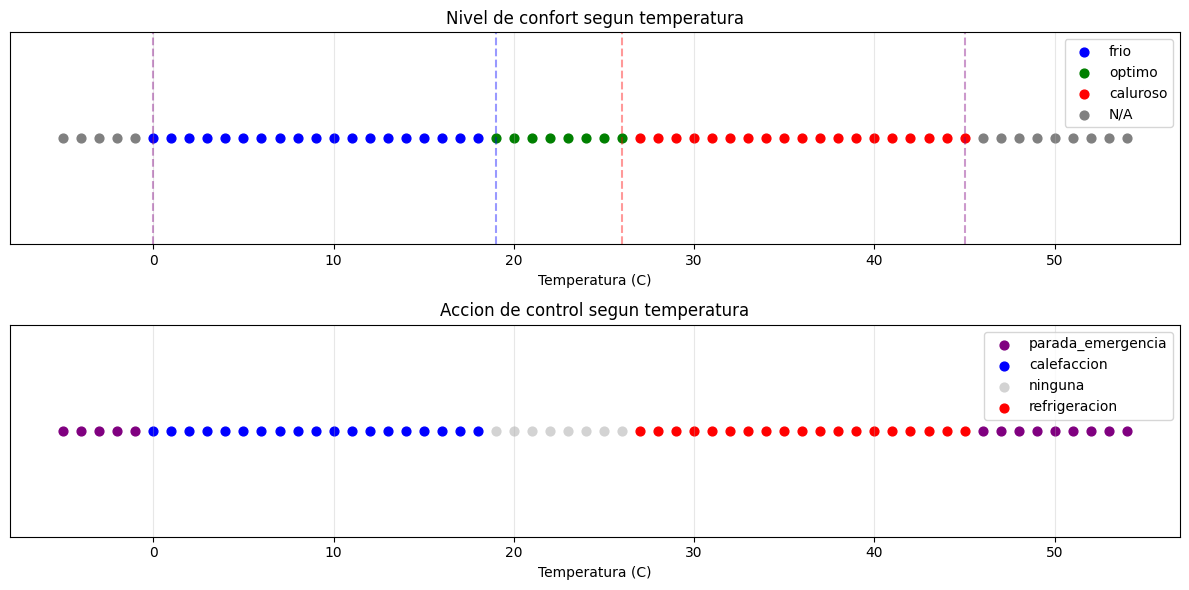


Transiciones del sistema:
-------------------------------------------------------
    T < 0C -> confort=N/A, accion=parada_emergencia, emergencia=SI
     0-18C -> confort=frio, accion=calefaccion, emergencia=NO
    19-26C -> confort=optimo, accion=ninguna, emergencia=NO
    27-44C -> confort=caluroso, accion=refrigeracion, emergencia=NO
   T > 45C -> confort=N/A, accion=parada_emergencia, emergencia=SI


In [13]:
# =============================================
# ANALISIS DE SENSIBILIDAD: TEMPERATURA
# =============================================
# Probamos todas las temperaturas de -5 a 54 grados para ver
# como cambia la respuesta del sistema. Esto sirve para comprobar
# que las transiciones entre rangos son limpias y no hay solapamientos.

temperaturas = list(range(-5, 55, 1))
resultados_sens = []

for temp in temperaturas:
    # Para cada temperatura, creamos el motor, metemos los datos y ejecutamos
    engine = ControlClimatico()
    engine.reset()
    engine.declare(SensorTemperatura(zona="test", valor=float(temp)))
    engine.declare(SensorCO2(zona="test", ppm=500.0))       # CO2 normal
    engine.declare(SensorOcupacion(zona="test", personas=10)) # 10 personas
    engine.run()

    # Recogemos los resultados de cada ejecucion
    acciones = [h for h in engine.facts.values() if isinstance(h, AccionControl)]
    alertas = [h for h in engine.facts.values() if isinstance(h, Alerta)]
    confort = [h for h in engine.facts.values() if isinstance(h, NivelConfort)]

    resultados_sens.append({
        'temperatura': temp,
        'confort': confort[0]['nivel'] if confort else 'N/A',
        'accion_principal': acciones[0]['accion'] if acciones else 'ninguna',
        'emergencia': any(a['prioridad'] == 'critica' for a in alertas)
    })

df_sens = pd.DataFrame(resultados_sens)

# --- Graficos ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))

# Grafico 1: nivel de confort segun temperatura
colores = {'frio': 'blue', 'optimo': 'green', 'caluroso': 'red', 'N/A': 'gray'}
for nivel, color in colores.items():
    mask = df_sens['confort'] == nivel
    ax1.scatter(df_sens.loc[mask, 'temperatura'], [1]*mask.sum(), c=color, label=nivel, s=40)

# Lineas verticales en los umbrales
ax1.axvline(x=0, color='purple', linestyle='--', alpha=0.4)   # emergencia frio
ax1.axvline(x=19, color='blue', linestyle='--', alpha=0.4)    # frio -> optimo
ax1.axvline(x=26, color='red', linestyle='--', alpha=0.4)     # optimo -> caluroso
ax1.axvline(x=45, color='purple', linestyle='--', alpha=0.4)  # emergencia calor
ax1.set_xlabel('Temperatura (C)')
ax1.set_title('Nivel de confort segun temperatura')
ax1.legend()
ax1.set_yticks([])
ax1.grid(True, alpha=0.3)

# Grafico 2: accion de control segun temperatura
colores_acc = {'calefaccion': 'blue', 'ninguna': 'lightgray',
               'refrigeracion': 'red', 'parada_emergencia': 'purple'}
for acc in df_sens['accion_principal'].unique():
    mask = df_sens['accion_principal'] == acc
    ax2.scatter(df_sens.loc[mask, 'temperatura'], [1]*mask.sum(),
                c=colores_acc.get(acc, 'gray'), label=acc, s=40)

ax2.set_xlabel('Temperatura (C)')
ax2.set_title('Accion de control segun temperatura')
ax2.legend()
ax2.set_yticks([])
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Resumen por rangos (para ver las transiciones claras)
print("\nTransiciones del sistema:")
print("-" * 55)
for (low, high), label in [((-5,-1),'T < 0C'), ((0,18),'0-18C'),
                            ((19,26),'19-26C'), ((27,44),'27-44C'), ((45,54),'T > 45C')]:
    sub = df_sens[(df_sens['temperatura'] >= low) & (df_sens['temperatura'] <= high)]
    if len(sub) > 0:
        c = sub['confort'].mode().iloc[0]
        a = sub['accion_principal'].mode().iloc[0]
        e = 'SI' if sub['emergencia'].any() else 'NO'
        print(f"  {label:>8} -> confort={c}, accion={a}, emergencia={e}")

In [14]:
# =============================================
# ANALISIS DE SENSIBILIDAD: CO2
# =============================================
# Lo mismo que arriba pero variando el CO2 en vez de la temperatura.
# La temperatura se deja fija en 22C (optima) para aislar el efecto del CO2.

niveles_co2 = list(range(200, 6000, 100))
res_co2 = []

for co2 in niveles_co2:
    engine = ControlClimatico()
    engine.reset()
    engine.declare(SensorTemperatura(zona="test", valor=22.0))  # temp fija
    engine.declare(SensorCO2(zona="test", ppm=float(co2)))
    engine.declare(SensorOcupacion(zona="test", personas=10))
    engine.run()

    acciones = [h for h in engine.facts.values() if isinstance(h, AccionControl)]
    alertas = [h for h in engine.facts.values() if isinstance(h, Alerta)]
    calidad = [h for h in engine.facts.values() if isinstance(h, NivelCalidadAire)]

    res_co2.append({
        'co2': co2,
        'calidad_aire': calidad[0]['nivel'] if calidad else 'N/A',
        'ventilacion': any(a['accion'] in ('ventilacion', 'ventilacion_emergencia') for a in acciones),
        'emergencia': any(a['prioridad'] == 'critica' for a in alertas)
    })

df_co2 = pd.DataFrame(res_co2)

# Resumen por rangos
print("Respuesta del sistema segun nivel de CO2:")
print("-" * 50)
for (low, high), label in [((200,400),'<=400 ppm'), ((401,1000),'401-1000 ppm'),
                            ((1001,5000),'1001-5000 ppm'), ((5001,6000),'>5000 ppm')]:
    sub = df_co2[(df_co2['co2'] >= low) & (df_co2['co2'] <= high)]
    if len(sub) > 0:
        cal = sub['calidad_aire'].mode().iloc[0]
        vent = 'SI' if sub['ventilacion'].any() else 'NO'
        emerg = 'SI' if sub['emergencia'].any() else 'NO'
        print(f"  {label:>15} -> calidad={cal}, ventilacion={vent}, emergencia={emerg}")

  Clasificacion: Zona 'test' -> aire BUENO
  Clasificacion: Zona 'test' -> OPTIMO
  Clasificacion: Zona 'test' -> aire BUENO
  Clasificacion: Zona 'test' -> OPTIMO
  Clasificacion: Zona 'test' -> aire BUENO
  Clasificacion: Zona 'test' -> OPTIMO
  Clasificacion: Zona 'test' -> aire REGULAR
  Clasificacion: Zona 'test' -> OPTIMO
  Clasificacion: Zona 'test' -> aire REGULAR
  Clasificacion: Zona 'test' -> OPTIMO


  Clasificacion: Zona 'test' -> aire REGULAR
  Clasificacion: Zona 'test' -> OPTIMO
  Clasificacion: Zona 'test' -> aire REGULAR
  Clasificacion: Zona 'test' -> OPTIMO


  Clasificacion: Zona 'test' -> aire REGULAR
  Clasificacion: Zona 'test' -> OPTIMO
  Clasificacion: Zona 'test' -> aire REGULAR
  Clasificacion: Zona 'test' -> OPTIMO
  Clasificacion: Zona 'test' -> aire MALO
  Clasificacion: Zona 'test' -> OPTIMO
  Control: Zona 'test' -> VENTILACION forzada
  Clasificacion: Zona 'test' -> aire MALO
  Clasificacion: Zona 'test' -> OPTIMO
  Control: Zona 'test' -> VENTILACION forzada
  Clasificacion: Zona 'test' -> aire MALO
  Clasificacion: Zona 'test' -> OPTIMO
  Control: Zona 'test' -> VENTILACION forzada
  Clasificacion: Zona 'test' -> aire MALO
  Clasificacion: Zona 'test' -> OPTIMO
  Control: Zona 'test' -> VENTILACION forzada
  Clasificacion: Zona 'test' -> aire MALO
  Clasificacion: Zona 'test' -> OPTIMO
  Control: Zona 'test' -> VENTILACION forzada
  Clasificacion: Zona 'test' -> aire MALO
  Clasificacion: Zona 'test' -> OPTIMO
  Control: Zona 'test' -> VENTILACION forzada
  Clasificacion: Zona 'test' -> aire MALO
  Clasificacion: Zona 'test'

  Clasificacion: Zona 'test' -> aire MALO
  Clasificacion: Zona 'test' -> OPTIMO
  Control: Zona 'test' -> VENTILACION forzada
  Clasificacion: Zona 'test' -> aire MALO
  Clasificacion: Zona 'test' -> OPTIMO
  Control: Zona 'test' -> VENTILACION forzada
  Clasificacion: Zona 'test' -> aire MALO
  Clasificacion: Zona 'test' -> OPTIMO
  Control: Zona 'test' -> VENTILACION forzada
  Clasificacion: Zona 'test' -> aire MALO
  Clasificacion: Zona 'test' -> OPTIMO
  Control: Zona 'test' -> VENTILACION forzada
  Clasificacion: Zona 'test' -> aire MALO
  Clasificacion: Zona 'test' -> OPTIMO
  Control: Zona 'test' -> VENTILACION forzada
  Clasificacion: Zona 'test' -> aire MALO
  Clasificacion: Zona 'test' -> OPTIMO
  Control: Zona 'test' -> VENTILACION forzada
  Clasificacion: Zona 'test' -> aire MALO
  Clasificacion: Zona 'test' -> OPTIMO
  Control: Zona 'test' -> VENTILACION forzada
  Clasificacion: Zona 'test' -> aire MALO
  Clasificacion: Zona 'test' -> OPTIMO
  Control: Zona 'test' -> VENT

  Clasificacion: Zona 'test' -> aire MALO
  Clasificacion: Zona 'test' -> OPTIMO
  Control: Zona 'test' -> VENTILACION forzada
  Clasificacion: Zona 'test' -> aire MALO
  Clasificacion: Zona 'test' -> OPTIMO
  Control: Zona 'test' -> VENTILACION forzada
  Clasificacion: Zona 'test' -> aire MALO
  Clasificacion: Zona 'test' -> OPTIMO
  Control: Zona 'test' -> VENTILACION forzada
  Clasificacion: Zona 'test' -> aire MALO
  Clasificacion: Zona 'test' -> OPTIMO
  Control: Zona 'test' -> VENTILACION forzada
  Clasificacion: Zona 'test' -> aire MALO
  Clasificacion: Zona 'test' -> OPTIMO
  Control: Zona 'test' -> VENTILACION forzada
  Clasificacion: Zona 'test' -> aire MALO
  Clasificacion: Zona 'test' -> OPTIMO
  Control: Zona 'test' -> VENTILACION forzada
  Clasificacion: Zona 'test' -> aire MALO
  Clasificacion: Zona 'test' -> OPTIMO
  Control: Zona 'test' -> VENTILACION forzada
  Clasificacion: Zona 'test' -> aire MALO
  Clasificacion: Zona 'test' -> OPTIMO
  Control: Zona 'test' -> VENT

  Clasificacion: Zona 'test' -> aire MALO
  Clasificacion: Zona 'test' -> OPTIMO
  Control: Zona 'test' -> VENTILACION forzada
  Clasificacion: Zona 'test' -> aire MALO
  Clasificacion: Zona 'test' -> OPTIMO
  Control: Zona 'test' -> VENTILACION forzada
  Clasificacion: Zona 'test' -> aire MALO
  Clasificacion: Zona 'test' -> OPTIMO
  Control: Zona 'test' -> VENTILACION forzada
  Clasificacion: Zona 'test' -> aire MALO
  Clasificacion: Zona 'test' -> OPTIMO
  Control: Zona 'test' -> VENTILACION forzada


  Clasificacion: Zona 'test' -> aire MALO
  Clasificacion: Zona 'test' -> OPTIMO
  Control: Zona 'test' -> VENTILACION forzada
  Clasificacion: Zona 'test' -> aire MALO
  Clasificacion: Zona 'test' -> OPTIMO
  Control: Zona 'test' -> VENTILACION forzada
  Clasificacion: Zona 'test' -> aire MALO
  Clasificacion: Zona 'test' -> OPTIMO
  Control: Zona 'test' -> VENTILACION forzada
  Clasificacion: Zona 'test' -> aire MALO
  Clasificacion: Zona 'test' -> OPTIMO
  Control: Zona 'test' -> VENTILACION forzada
  Clasificacion: Zona 'test' -> aire MALO
  Clasificacion: Zona 'test' -> OPTIMO
  Control: Zona 'test' -> VENTILACION forzada
  Clasificacion: Zona 'test' -> aire MALO
  Clasificacion: Zona 'test' -> OPTIMO
  Control: Zona 'test' -> VENTILACION forzada
  Clasificacion: Zona 'test' -> aire MALO
  Clasificacion: Zona 'test' -> OPTIMO
  Control: Zona 'test' -> VENTILACION forzada
  Clasificacion: Zona 'test' -> aire MALO
  Clasificacion: Zona 'test' -> OPTIMO
  Control: Zona 'test' -> VENT

  EMERGENCIA: Zona 'test' - CO2 toxico (>5000 ppm)
  EMERGENCIA: Zona 'test' - CO2 toxico (>5000 ppm)
  EMERGENCIA: Zona 'test' - CO2 toxico (>5000 ppm)
  EMERGENCIA: Zona 'test' - CO2 toxico (>5000 ppm)
  EMERGENCIA: Zona 'test' - CO2 toxico (>5000 ppm)
  EMERGENCIA: Zona 'test' - CO2 toxico (>5000 ppm)


  EMERGENCIA: Zona 'test' - CO2 toxico (>5000 ppm)
  EMERGENCIA: Zona 'test' - CO2 toxico (>5000 ppm)
Respuesta del sistema segun nivel de CO2:
--------------------------------------------------
        <=400 ppm -> calidad=bueno, ventilacion=NO, emergencia=NO
     401-1000 ppm -> calidad=regular, ventilacion=NO, emergencia=NO
    1001-5000 ppm -> calidad=malo, ventilacion=SI, emergencia=NO
        >5000 ppm -> calidad=N/A, ventilacion=SI, emergencia=SI


## Tests
12 tests que comprueban los distintos comportamientos del sistema.

In [15]:
# =============================================
# TESTS
# =============================================
# 12 tests que comprueban que el sistema funciona bien en distintas situaciones.
# Cada test crea el motor, mete unos hechos concretos y comprueba que
# la salida sea la esperada.
#
# La funcion 'comprobar' devuelve (True/False, mensaje de error).
# Si devuelve True el test pasa, si devuelve False falla y muestra el mensaje.

def hacer_test(test_id, nombre, hechos, comprobar):
    """Ejecuta un test individual y dice si pasa o falla"""
    engine = ControlClimatico()
    engine.reset()
    for h in hechos:
        engine.declare(h)
    engine.run()

    ok, msg = comprobar(engine)
    estado = 'PASS' if ok else 'FAIL'
    print(f"  [{estado}] {test_id}: {nombre}")
    if not ok:
        print(f"         -> {msg}")
    return ok, test_id, nombre

print("Ejecutando tests...")
print("=" * 55)

resultados = []

# --- T01: temperatura baja con gente -> calefaccion ---
ok, tid, tn = hacer_test("T01", "Temp baja activa calefaccion",
    [SensorTemperatura(zona="test", valor=15.0),
     SensorCO2(zona="test", ppm=500.0),
     SensorOcupacion(zona="test", personas=5)],
    lambda e: (
        any(isinstance(h, AccionControl) and h['accion'] == 'calefaccion' for h in e.facts.values()),
        "No se activo la calefaccion"
    ))
resultados.append((ok, tid, tn))

# --- T02: temperatura alta con gente -> refrigeracion ---
ok, tid, tn = hacer_test("T02", "Temp alta activa refrigeracion",
    [SensorTemperatura(zona="test", valor=32.0),
     SensorCO2(zona="test", ppm=500.0),
     SensorOcupacion(zona="test", personas=3)],
    lambda e: (
        any(isinstance(h, AccionControl) and h['accion'] == 'refrigeracion' for h in e.facts.values()),
        "No se activo la refrigeracion"
    ))
resultados.append((ok, tid, tn))

# --- T03: CO2 alto -> ventilacion ---
ok, tid, tn = hacer_test("T03", "CO2 alto activa ventilacion",
    [SensorTemperatura(zona="test", valor=22.0),
     SensorCO2(zona="test", ppm=1500.0),
     SensorOcupacion(zona="test", personas=5)],
    lambda e: (
        any(isinstance(h, AccionControl) and h['accion'] == 'ventilacion' for h in e.facts.values()),
        "No se activo ventilacion"
    ))
resultados.append((ok, tid, tn))

# --- T04: todo bien -> no hace nada especial ---
ok, tid, tn = hacer_test("T04", "Condiciones optimas, sin accion HVAC",
    [SensorTemperatura(zona="test", valor=22.0),
     SensorCO2(zona="test", ppm=400.0),
     SensorOcupacion(zona="test", personas=5)],
    lambda e: (
        # Tiene que clasificar como optimo pero NO activar calefaccion ni refrigeracion
        any(isinstance(h, NivelConfort) and h['nivel'] == 'optimo' for h in e.facts.values()) and
        not any(isinstance(h, AccionControl) and h['accion'] in ('calefaccion', 'refrigeracion') for h in e.facts.values()),
        "Deberia estar en optimo sin acciones de climatizacion"
    ))
resultados.append((ok, tid, tn))

# --- T05: inferencia multinivel (sensor -> clasificacion -> accion) ---
# Este test comprueba que la cadena funciona: primero clasifica como frio,
# y LUEGO esa clasificacion dispara la regla de calefaccion
ok, tid, tn = hacer_test("T05", "Inferencia multinivel: sensor -> confort -> accion",
    [SensorTemperatura(zona="test", valor=15.0),
     SensorCO2(zona="test", ppm=500.0),
     SensorOcupacion(zona="test", personas=3)],
    lambda e: (
        any(isinstance(h, NivelConfort) and h['nivel'] == 'frio' for h in e.facts.values()) and
        any(isinstance(h, AccionControl) and h['accion'] == 'calefaccion' for h in e.facts.values()),
        "Deberia haber NivelConfort(frio) y luego calefaccion"
    ))
resultados.append((ok, tid, tn))

# --- T06: riesgo energetico reduce la intensidad ---
# Mucha gente + calor -> refrigeracion, pero la regla de optimizacion
# detecta el riesgo energetico y baja la intensidad a moderada
ok, tid, tn = hacer_test("T06", "Riesgo energetico reduce intensidad",
    [SensorTemperatura(zona="test", valor=30.0),
     SensorCO2(zona="test", ppm=500.0),
     SensorOcupacion(zona="test", personas=50)],
    lambda e: (
        any(isinstance(h, RiesgoEnergetico) for h in e.facts.values()) and
        any(isinstance(h, AccionControl) and h['accion'] == 'refrigeracion' and h['intensidad'] == 'moderada' for h in e.facts.values()),
        "Deberia haber riesgo energetico y refrigeracion moderada (no alta)"
    ))
resultados.append((ok, tid, tn))

# --- T07: prediccion activa pre-enfriamiento ---
# La temp actual esta bien (24C) pero la prediccion dice que va a subir
ok, tid, tn = hacer_test("T07", "Prediccion activa pre-enfriamiento",
    [SensorTemperatura(zona="test", valor=24.0),
     SensorCO2(zona="test", ppm=500.0),
     SensorOcupacion(zona="test", personas=8),
     PrediccionTemperatura(zona="test", valor_futuro=30.0, horizonte_min=30)],
    lambda e: (
        any(isinstance(h, AccionControl) and h['accion'] == 'pre_enfriamiento' for h in e.facts.values()),
        "No se activo el pre-enfriamiento"
    ))
resultados.append((ok, tid, tn))

# --- T08: emergencia tiene prioridad maxima ---
ok, tid, tn = hacer_test("T08", "Emergencia tiene prioridad",
    [SensorTemperatura(zona="test", valor=50.0),
     SensorCO2(zona="test", ppm=500.0),
     SensorOcupacion(zona="test", personas=5)],
    lambda e: (
        any(isinstance(h, Alerta) and h['prioridad'] == 'critica' for h in e.facts.values()),
        "No se genero alerta critica"
    ))
resultados.append((ok, tid, tn))

# --- T09: zona vacia con temp optima -> modo ahorro ---
ok, tid, tn = hacer_test("T09", "Modo ahorro en zona vacia",
    [SensorTemperatura(zona="test", valor=22.0),
     SensorCO2(zona="test", ppm=350.0),
     SensorOcupacion(zona="test", personas=0)],
    lambda e: (
        any(isinstance(h, AccionControl) and h['accion'] == 'modo_ahorro' for h in e.facts.values()),
        "No se activo modo ahorro"
    ))
resultados.append((ok, tid, tn))

# --- T10: caso limite, justo en el umbral (19.0 = optimo, no frio) ---
ok, tid, tn = hacer_test("T10", "Umbral exacto: 19.0C es optimo",
    [SensorTemperatura(zona="test", valor=19.0),
     SensorCO2(zona="test", ppm=500.0),
     SensorOcupacion(zona="test", personas=5)],
    lambda e: (
        any(isinstance(h, NivelConfort) and h['nivel'] == 'optimo' for h in e.facts.values()),
        "19.0 deberia ser optimo"
    ))
resultados.append((ok, tid, tn))

# --- T11: datos incompletos (solo ocupacion, sin temperatura) ---
# El sistema no deberia hacer nada raro ni petar
ok, tid, tn = hacer_test("T11", "Sin sensores de temp no hace nada raro",
    [SensorOcupacion(zona="test", personas=5)],
    lambda e: (
        not any(isinstance(h, AccionControl) for h in e.facts.values()) and
        not any(isinstance(h, Alerta) for h in e.facts.values()),
        "No deberia generar acciones sin temperatura"
    ))
resultados.append((ok, tid, tn))

# --- T12: dos zonas con condiciones opuestas ---
# Zona A fria y zona B caliente, tiene que manejarlas por separado
ok, tid, tn = hacer_test("T12", "Dos zonas funcionan independientes",
    [SensorTemperatura(zona="zona_A", valor=15.0),
     SensorCO2(zona="zona_A", ppm=500.0),
     SensorOcupacion(zona="zona_A", personas=5),
     SensorTemperatura(zona="zona_B", valor=30.0),
     SensorCO2(zona="zona_B", ppm=500.0),
     SensorOcupacion(zona="zona_B", personas=5)],
    lambda e: (
        any(isinstance(h, AccionControl) and h['zona'] == 'zona_A' and h['accion'] == 'calefaccion' for h in e.facts.values()) and
        any(isinstance(h, AccionControl) and h['zona'] == 'zona_B' and h['accion'] == 'refrigeracion' for h in e.facts.values()),
        "Deberia haber calefaccion en A y refrigeracion en B"
    ))
resultados.append((ok, tid, tn))

# --- RESUMEN FINAL ---
print("\n" + "=" * 55)
pasados = sum(1 for ok, _, _ in resultados if ok)
print(f"Resultado: {pasados}/{len(resultados)} tests pasados")
for ok, tid, nombre in resultados:
    print(f"  {'PASS' if ok else 'FAIL'} - {tid}: {nombre}")

Ejecutando tests...
  Clasificacion: Zona 'test' -> aire REGULAR
  Clasificacion: Zona 'test' -> FRIO
  Control: Zona 'test' -> activar CALEFACCION
  [PASS] T01: Temp baja activa calefaccion
  Clasificacion: Zona 'test' -> aire REGULAR
  Clasificacion: Zona 'test' -> CALUROSO
  Control: Zona 'test' -> activar REFRIGERACION
  [PASS] T02: Temp alta activa refrigeracion
  Clasificacion: Zona 'test' -> aire MALO
  Clasificacion: Zona 'test' -> OPTIMO
  Control: Zona 'test' -> VENTILACION forzada
  [PASS] T03: CO2 alto activa ventilacion
  Clasificacion: Zona 'test' -> aire BUENO
  Clasificacion: Zona 'test' -> OPTIMO
  [PASS] T04: Condiciones optimas, sin accion HVAC


  Clasificacion: Zona 'test' -> aire REGULAR
  Clasificacion: Zona 'test' -> FRIO
  Control: Zona 'test' -> activar CALEFACCION
  [PASS] T05: Inferencia multinivel: sensor -> confort -> accion
  Clasificacion: Zona 'test' -> aire REGULAR
  Clasificacion: Zona 'test' -> CALUROSO
  Clasificacion: Zona 'test' -> riesgo energetico ALTO
  Control: Zona 'test' -> activar REFRIGERACION
  Optimizacion: Zona 'test' -> bajar refrigeracion a MODERADA
  Optimizacion: Zona 'test' -> ventilacion preventiva
  [PASS] T06: Riesgo energetico reduce intensidad
  Clasificacion: Zona 'test' -> aire REGULAR
  Clasificacion: Zona 'test' -> OPTIMO
  Control predictivo: Zona 'test' -> PRE-ENFRIAMIENTO
  [PASS] T07: Prediccion activa pre-enfriamiento
  EMERGENCIA: Zona 'test' - temperatura extrema
  Clasificacion: Zona 'test' -> aire REGULAR
  [PASS] T08: Emergencia tiene prioridad


  Clasificacion: Zona 'test' -> aire BUENO


  Clasificacion: Zona 'test' -> OPTIMO
  Control: Zona 'test' -> MODO AHORRO (vacia)
  [PASS] T09: Modo ahorro en zona vacia
  Clasificacion: Zona 'test' -> aire REGULAR
  Clasificacion: Zona 'test' -> OPTIMO
  [PASS] T10: Umbral exacto: 19.0C es optimo
  [PASS] T11: Sin sensores de temp no hace nada raro
  Clasificacion: Zona 'zona_B' -> aire REGULAR
  Clasificacion: Zona 'zona_B' -> CALUROSO
  Clasificacion: Zona 'zona_A' -> aire REGULAR
  Clasificacion: Zona 'zona_A' -> FRIO
  Control: Zona 'zona_A' -> activar CALEFACCION
  Control: Zona 'zona_B' -> activar REFRIGERACION
  [PASS] T12: Dos zonas funcionan independientes

Resultado: 12/12 tests pasados
  PASS - T01: Temp baja activa calefaccion
  PASS - T02: Temp alta activa refrigeracion
  PASS - T03: CO2 alto activa ventilacion
  PASS - T04: Condiciones optimas, sin accion HVAC
  PASS - T05: Inferencia multinivel: sensor -> confort -> accion
  PASS - T06: Riesgo energetico reduce intensidad
  PASS - T07: Prediccion activa pre-enfri

## Conclusiones

El sistema funciona bien en todos los escenarios que he probado. Lo que mas me ha costado
entender es que el orden de las reglas importa mucho, sin el salience las reglas de control
se ejecutaban antes que las de clasificacion y no funcionaba.

Tambien tuve problemas con las acciones duplicadas hasta que use NOT() para comprobar
que no existiera ya la accion antes de crearla.

La parte de series temporales esta bien porque permite que el sistema actue de forma
preventiva en vez de solo reactiva. Solo predice temperatura pero se podria hacer
lo mismo con el CO2 o la ocupacion.